### 2장. 딥러닝 핵심 미리보기

#### '폐암 수술 환자의 생존율 예측' 코드 미리보기

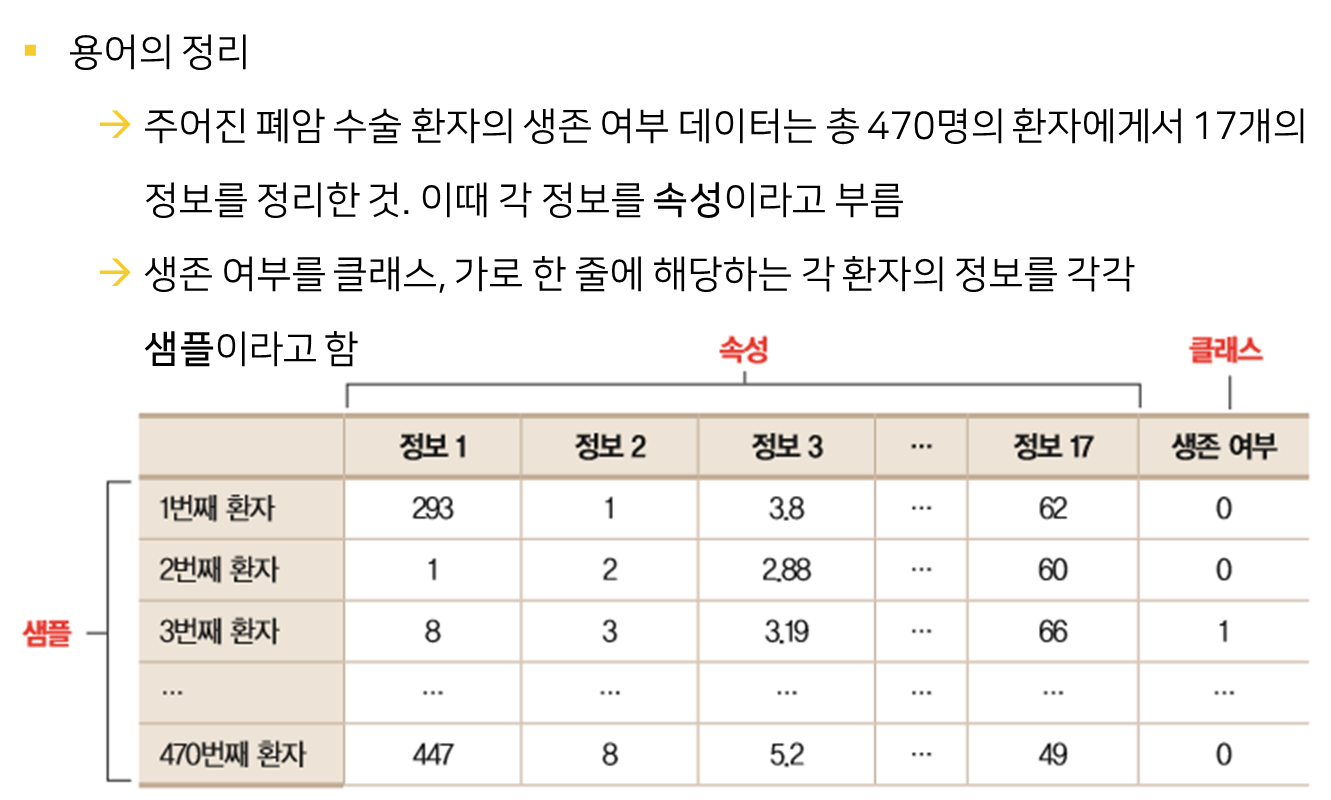

**딥러닝 개괄하기**
* 앞으로 다루게 될 폐암 수술 환자의 수술 1년 후 생존율을 예측한 모델
* 코드를 개괄적으로 살펴보며 딥러닝을 프로그래밍하는 과정에 대한 감을 잡아 보자
* 단 몇 줄로 이루어진 간략한 코드는 다음과 같이 크게 네 부분으로 나뉘어 있음


```bash
conda create -n py310_tf210 python==3.10
conda activate py310_tf210
pip install jupyter ipykernel
pip install numpy==1.23.5
pip install tensorflow==2.10
```

In [ ]:
#####################################################################
# 딥러닝 샘플코드 : 폐암 수술 환자의 생존율 예측 코드
#####################################################################
# 딥러닝을 구동하는 데 필요한 라이브러리를 불러옵니다.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

# 준비된 수술 환자 데이터를 불러들입니다.
data_set = np.loadtxt("./data/ThoraricSurgery3.csv", delimiter=",")

# 환자의 기록과 수술 결과를 X와 Y로 구분하여 저장합니다.
X = data_set[:, :-1] # shape : (470, 16)
y = data_set[:, 16]  # shape : (470,) -> label : 1(생존), 0(사망) -> 2진분류(지도학습)

# 딥러닝 구조를 결정합니다(모델을 설정하고 실행하는 부분입니다).
model = Sequential()
model.add(Dense(30, input_dim=16, activation='relu')) # hidden layer 
model.add(Dense(1, activation='sigmoid')) # 마지막 1개의 답을 도출하기 위해 sigmoid

# 딥러닝을 실행합니다.
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X, y, epochs=100, batch_size=10)

# 결과를 출력합니다. 
print("\n Accuracy: %.4f" % (model.evaluate(X, y)[1]))

Epoch 1/100
47/47 [==============================] - 5s 8ms/step - loss: 0.9874 - accuracy: 0.6809
Epoch 2/100
47/47 [==============================] - 0s 8ms/step - loss: 0.4748 - accuracy: 0.8447
Epoch 3/100
47/47 [==============================] - 0s 5ms/step - loss: 0.4638 - accuracy: 0.8489
Epoch 4/100
47/47 [==============================] - 0s 7ms/step - loss: 0.4685 - accuracy: 0.8511
Epoch 5/100
47/47 [==============================] - 0s 7ms/step - loss: 0.4518 - accuracy: 0.8511
Epoch 6/100
47/47 [==============================] - 2s 35ms/step - loss: 0.4434 - accuracy: 0.8511
Epoch 7/100
47/47 [==============================] - 2s 45ms/step - loss: 0.4386 - accuracy: 0.8511
Epoch 8/100
47/47 [==============================] - 1s 26ms/step - loss: 0.4375 - accuracy: 0.8511
Epoch 9/100
47/47 [==============================] - 1s 25ms/step - loss: 0.4265 - accuracy: 0.8511
Epoch 10/100
47/47 [==============================] - 1s 17ms/step - loss: 0.4208 - accuracy: 0.8511
Epoc

In [2]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 30)                510       
                                                                 
 dense_1 (Dense)             (None, 1)                 31        
                                                                 
Total params: 541
Trainable params: 541
Non-trainable params: 0
_________________________________________________________________


### 1. 환경 준비 

In [1]:
from tensorflow.keras.models import Sequential  # 텐서플로의 케라스 API에서 필요한 함수들을 불러옵니다.
from tensorflow.keras.layers import Dense       # 데이터를 다루는데 필요한 라이브러리를 불러옵니다.
import numpy as np

### 2. 데이터 준비

In [2]:
Data_set = np.loadtxt("./data/ThoraricSurgery3.csv", delimiter=",") # 준비된 수술 환자 데이터를 불러옵니다.
X = Data_set[:,:-1]                                                 # 환자의 진찰 기록을 X로 지정합니다.
y = Data_set[:,-1]                                         # 수술 후 사망/생존 여부를 y로 지정합니다.

In [3]:
X.shape, y.shape

((470, 16), (470,))

In [4]:
X[:3], y[:3]

(array([[ 1.  ,  2.88,  2.16,  1.  ,  0.  ,  0.  ,  0.  ,  1.  ,  1.  ,
          3.  ,  0.  ,  0.  ,  0.  ,  1.  ,  0.  , 60.  ],
        [ 2.  ,  3.4 ,  1.88,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
          1.  ,  0.  ,  0.  ,  0.  ,  1.  ,  0.  , 51.  ],
        [ 2.  ,  2.76,  2.08,  1.  ,  0.  ,  0.  ,  0.  ,  1.  ,  0.  ,
          0.  ,  0.  ,  0.  ,  0.  ,  1.  ,  0.  , 59.  ]]),
 array([0., 0., 0.]))

### 3. 구조 결정 

In [5]:
model = Sequential()                                                  # 딥러닝 모델의 구조를 결정합니다.
model.add(Dense(30, input_dim=16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

### 4. 모델 실행 

In [6]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])  # 딥러닝 모델을 실행합니다.
history = model.fit(X, y, epochs=100, batch_size=16)

Epoch 1/100
30/30 [==============================] - 1s 3ms/step - loss: 1.0099 - accuracy: 0.8511
Epoch 2/100
30/30 [==============================] - 0s 3ms/step - loss: 0.4782 - accuracy: 0.8511
Epoch 3/100
30/30 [==============================] - 0s 2ms/step - loss: 0.4717 - accuracy: 0.8511
Epoch 4/100
30/30 [==============================] - 0s 2ms/step - loss: 0.4794 - accuracy: 0.8511
Epoch 5/100
30/30 [==============================] - 0s 2ms/step - loss: 0.4595 - accuracy: 0.8511
Epoch 6/100
30/30 [==============================] - 0s 2ms/step - loss: 0.4580 - accuracy: 0.8511
Epoch 7/100
30/30 [==============================] - 0s 2ms/step - loss: 0.4565 - accuracy: 0.8511
Epoch 8/100
30/30 [==============================] - 0s 2ms/step - loss: 0.4477 - accuracy: 0.8511
Epoch 9/100
30/30 [==============================] - 0s 2ms/step - loss: 0.4582 - accuracy: 0.8447
Epoch 10/100
30/30 [==============================] - 0s 2ms/step - loss: 0.4285 - accuracy: 0.8511
Epoch 11/

In [7]:
import pandas as pd

history.history

{'loss': [1.0099164247512817,
  0.47815605998039246,
  0.4716801047325134,
  0.4794274568557739,
  0.4595487117767334,
  0.4580414593219757,
  0.4565367102622986,
  0.4477289617061615,
  0.4582286477088928,
  0.4284648597240448,
  0.43295061588287354,
  0.4241609573364258,
  0.41069597005844116,
  0.45068052411079407,
  0.41173747181892395,
  0.40801358222961426,
  0.40265876054763794,
  0.4096831977367401,
  0.42131784558296204,
  0.4329129457473755,
  0.40219995379447937,
  0.41337186098098755,
  0.4081857204437256,
  0.4051152765750885,
  0.4009395241737366,
  0.4094184637069702,
  0.4221038818359375,
  0.40027227997779846,
  0.40764227509498596,
  0.39804285764694214,
  0.4152466058731079,
  0.4117791950702667,
  0.41077205538749695,
  0.3944654166698456,
  0.4065799415111542,
  0.3937218487262726,
  0.3995630443096161,
  0.41116344928741455,
  0.39694204926490784,
  0.396544486284256,
  0.41372397541999817,
  0.3891221284866333,
  0.4118199050426483,
  0.3900977671146393,
  0.3959

In [8]:
history.history.keys()

dict_keys(['loss', 'accuracy'])

In [15]:
import pandas as pd
pd.DataFrame(history.history)

,loss,accuracy
0,1.009916,0.851064
1,0.478156,0.851064
2,0.471680,0.851064
3,0.479427,0.851064
4,0.459549,0.851064
...,...,...
95,0.389029,0.842553
96,0.388666,0.857447
97,0.390256,0.855319
98,0.434015,0.840426


<Axes: >

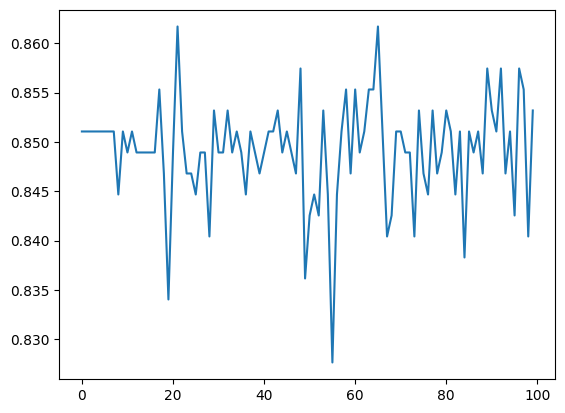

In [10]:
pd.DataFrame(history.history)['accuracy'].plot()

<Axes: >

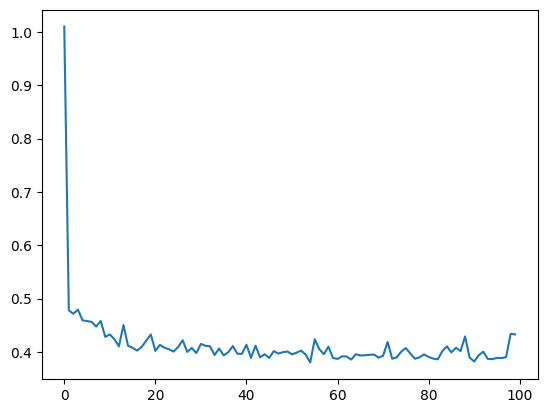

In [11]:
pd.DataFrame(history.history)['loss'].plot()

In [12]:
# 100~105번째 환자의 진찰 기록과 수술 결과 출력
X[100:105]

array([[ 2.  ,  3.36,  2.67,  1.  ,  0.  ,  0.  ,  0.  ,  1.  ,  0.  ,
         0.  ,  0.  ,  0.  ,  0.  ,  1.  ,  0.  , 72.  ],
       [ 2.  ,  1.84,  1.64,  1.  ,  0.  ,  0.  ,  0.  ,  1.  ,  1.  ,
         1.  ,  1.  ,  0.  ,  0.  ,  1.  ,  0.  , 72.  ],
       [ 3.  ,  4.32,  3.24,  1.  ,  0.  ,  0.  ,  0.  ,  1.  ,  0.  ,
         1.  ,  0.  ,  0.  ,  0.  ,  1.  ,  0.  , 76.  ],
       [ 2.  ,  2.35,  1.64,  1.  ,  0.  ,  0.  ,  0.  ,  1.  ,  0.  ,
         0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  1.  , 59.  ],
       [ 2.  ,  2.84,  1.88,  1.  ,  0.  ,  0.  ,  0.  ,  1.  ,  0.  ,
         0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  , 53.  ]])

In [14]:
## 학습된 모델로 100~105번째 환자의 수술 후 생존 여부 예측
model.predict(X[100:105])

1/1 [==============================] - 0s 113ms/step


array([[0.02984729],
       [0.3131684 ],
       [0.04509916],
       [0.00687878],
       [0.0546957 ]], dtype=float32)

In [ ]:
model.evaluate(X[:10], y[:10])

1/1 [==============================] - 1s 578ms/step - loss: 0.8262 - accuracy: 0.7000


[0.8262125253677368, 0.699999988079071]

In [ ]:
(model.predict(X) > 0.5).sum()

In [ ]:
(model.predict(X[:10]) > 0.5)

In [ ]:
y[:10]

In [ ]:
# 딥러닝을 구동하는 데 필요한 라이브러리를 불러옵니다.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

# 준비된 수술 환자 데이터를 불러들입니다.
data_set = np.loadtxt("../data/ThoraricSurgery3.csv", delimiter=",")

# 환자의 기록과 수술 결과를 X와 Y로 구분하여 저장합니다.
X = data_set[:, 0:16]
y = data_set[:, 16]

# 딥러닝 구조를 결정합니다.
model = Sequential()
model.add(Dense(30, input_dim=16, activation='relu')) # 16개 input, 30개의 다음층, ReLU함수 사용
model.add(Dense(1, activation='sigmoid')) # Output Layer(출력층) : Sigmoid함수로

# 딥러닝을 실행합니다.
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X, y, epochs=100, batch_size=10)

In [ ]:

# 모델 평가 결과를 출력합니다.
loss, accuracy = model.evaluate(X, y)
print("\n Accuracy: %.4f" % accuracy)


In [ ]:

# 모델의 예측값 확인
predictions = model.predict(X)

# 예측값을 기본 임계값 0.5로 변환하여 0과 1로 분류
predictions_binary = (predictions >= 0.5).astype(int)
predictions_binary

In [ ]:
predictions_binary

In [ ]:

# 예측값과 분류 결과 일부 출력
print("\n첫 5개 데이터의 예측 확률값:")
print(predictions[:5].flatten())
print("임계값 0.5 적용 후 분류 결과 (0 또는 1):")
print(predictions_binary[:5].flatten())
print("실제 레이블 (y):")
print(y[:5])


In [ ]:
(predictions_binary.flatten() == y)

In [ ]:

# 정확도 직접 계산 (임계값 0.5 기준)
manual_accuracy = np.mean(predictions_binary.flatten() == y)
print("\n임계값 0.5로 계산한 수동 정확도: %.4f" % manual_accuracy)
print("model.evaluate로 계산한 정확도: %.4f" % accuracy)

In [ ]:
predictions = model.predict(X)
(predictions.flatten() > 0.5).astype(int)